In [1]:
from fastai.vision.all import *

d:\Desktop\Waste_Classifier\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# Dataset location
path = Path(r'D:\Desktop\Waste_Classifier_Dataset_v2')

#Extracts images from dataset
files = get_image_files(path)
print(f"Total images (Train + Valid): {len(files)}")

Total images (Train + Valid): 18739


In [17]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [32]:
#For second training run (448px)

waste_block_448 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='Train', valid_name='Test'),
    get_y=parent_label,
    # 1. ITEM TRANSFORMS: Forces the model to look at small patches of the material
    # min_scale=0.3 means it might zoom in 70% into the bottle texture
    item_tfms=Resize(640, method='squish'),
    # 2. BATCH TRANSFORMS: Geometric warping and lighting for material ID
    batch_tfms=[*aug_transforms(
                    size=448, 
                    min_scale=0.5,      # GPU handles the zoom for texture ID
                    max_warp=0.25,      # Distorts the bottle shape
                    max_rotate=35.0,    # Recognizes waste at any angle
                    max_lighting=0.4,   # Handles specular reflections on PET/Metal
                    do_flip=True, 
                    flip_vert=True      # Essential for random waste orientation
                ), 
                Normalize.from_stats(*imagenet_stats)]
)

dls_448 = waste_block_448.dataloaders(
    path,
    bs=4,               
    num_workers=2, 
    pin_memory=True
)

d:\Desktop\Waste_Classifier\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


d:\Desktop\Waste_Classifier\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


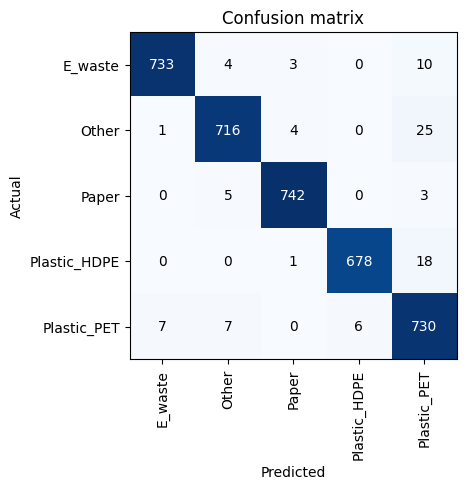

In [ ]:
# Load your saved model
learn = load_learner('waste_model_448_v2.pkl') 
learn.dls = dls_448
# Generate the matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

In [18]:
#For first training run (224px)

waste_block_224 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='Train', valid_name='Test'),
    get_y=parent_label,
    # 1. ITEM TRANSFORMS: Forces the model to look at small patches of the material
    # min_scale=0.3 means it might zoom in 70% into the bottle texture
    item_tfms=RandomResizedCrop(460, min_scale=0.3),
    # 2. BATCH TRANSFORMS: Geometric warping and lighting for material ID
    batch_tfms=[*aug_transforms(
                    size=224, 
                    max_warp=0.25,      # Distorts the bottle shape
                    max_rotate=35.0,    # Recognizes waste at any angle
                    max_lighting=0.4,   # Handles specular reflections on PET/Metal
                    do_flip=True, 
                    flip_vert=True      # Essential for random waste orientation
                ), 
                Normalize.from_stats(*imagenet_stats)]
)
dls_224 = waste_block_224.dataloaders(
    path,
    bs=6,
    num_workers=2,      # Uses multiple CPU cores to prep images
    pin_memory=True,     # Creates a "fast lane" from RAM to GPU
    prefetch_factor=2    # Preps the next batch while the current one is training
)

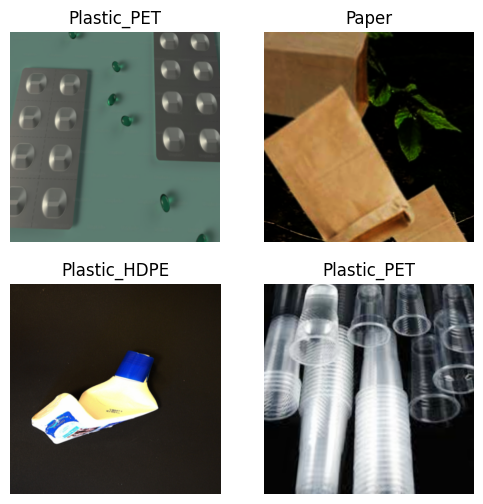

In [34]:
dls_448.show_batch()

<div></div>

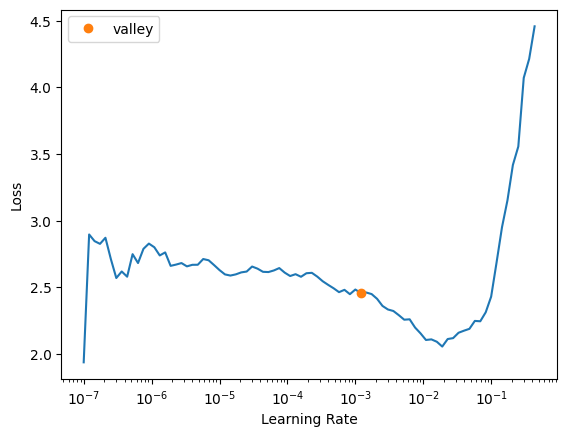

In [20]:
#For first training run (224px)

learn = vision_learner(dls_224, 'convnext_tiny', metrics=error_rate).to_fp16() #fp16() says python to uses 16bit math instead of 32bit math(increase speed)
lrs = learn.lr_find(suggest_funcs=(valley))

In [35]:
# Use this to prevent the progress bar from ever starting
import fastprogress
fastprogress.fastprogress.printing = lambda: True

from fastai.test_utils import *
#  the fine-tuning
with learn.no_bar():
    learn.fine_tune(3, base_lr=1e-4) #For first training run we use lr provided by valley algorithm  # 1e-4 (2nd run)

d:\Desktop\Waste_Classifier\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[0, 0.34492722153663635, 0.06366493552923203, 0.019496344029903412, '16:21']
[0, 0.19889090955257416, 0.07006252557039261, 0.021121039986610413, '16:51']
[1, 0.31096285581588745, 0.06330741941928864, 0.01814243197441101, '14:36']
[2, 0.2735427916049957, 0.06567887216806412, 0.01895477995276451, '14:38']


In [60]:
#Sample images to test
img = "D:\Desktop\HDPE_1.jpg"
pred, pred_idx, probs = learn.predict(img)

print(f"Prediction: {pred}")
print(f"Confidence: {probs[pred_idx]:.4f}")

Prediction: E_waste
Confidence: 0.5137


In [42]:
# 1. Load the exported model (The .pkl file we just made)
learn_inf = load_learner('waste_model_448_v2.pkl')

# 2. Test a single image
img_path = 'samples/e_waste_3_pred.jpg'
pred, pred_idx, probs = learn_inf.predict(img_path)

print(f"Prediction: {pred}; Probability: {probs[pred_idx]:.04f}")

Prediction: Other; Probability: 0.8557


In [40]:
learn.export('waste_model_448_v2.pkl')